# Notebook 01.4 — Visualização cartográfica e síntese da área de estudo

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA  
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI  
**Autor:** Felipe Ramos Dantas  
**Orientador:** Prof. Dr. Antonio Joaquim da Silva  
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais  
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs  
**Última atualização:** 2026-06-10

## Objetivo

Consolidar as aquisições dos notebooks **01.1 (IBGE)**, **01.2 (Overture)** e **01.3 (UBS/CNES)** em uma síntese da área de estudo: um quadro-resumo dos quantitativos espaciais e uma figura de detalhe da topologia (rede viária e edificações). Serve de contexto e de controle de qualidade visual antes das etapas de modelagem.

> Este notebook **não altera nenhum dado** — apenas lê e plota.

## Entrada

| Arquivo | Origem |
|---|---|
| `teresina_municipio.parquet`, `teresina_zonaUrbana_utm.parquet`, `teresina_zonaUrbana_buffer5kClip_utm.parquet` | NB 01.1 |
| `teresina_setoresCensitarios_DadosCompletos.parquet` | NB 01.1 |
| `zonaUrbana_5km_segmentos.parquet`, `zonaUrbana_5km_conectores.parquet`, `zonaUrbana_building_utm.geojson` | NB 01.2 |
| `teresina_zonaUrbana_buffer5km_ubs_capacidade.parquet` | NB 01.3 |

## Saídas

| Arquivo | Descrição |
|---|---|
| `outputs/tabelas/nb014/nb014_sintese_area_estudo.csv` | Quadro-síntese dos quantitativos da área de estudo |
| `outputs/figuras/nb014/nb014_fig02_topologia_detalhe.png` | Detalhe da topologia (rede viária + edificações) |

## Pré-requisitos

- NBs **01.1, 01.2 e 01.3** executados.
- Não altera dados — execução repetível à vontade.

---

## 1. Configuração e importações

Bibliotecas, caminhos, CRS e estilo cartográfico centralizados; criação das subpastas de saída (`nb014`).

In [ ]:
# ── 1. Imports e configuração ────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Caminhos, CRS e estilo cartografico centralizados (ver src/mapeprof/)
from mapeprof.config import (EXT_IBGE, EXT_OVERTURE, INT_MALHA, INT_UBS,
                             FIGURAS, TABELAS, CRS_METRICO)
from mapeprof.viz import (aplicar_estilo, barra_escala, seta_norte, moldura_mapa,
                          formatar_eixos_mapa, ajustar_zoom_camada)

aplicar_estilo()
FIGURAS_NB = FIGURAS / "nb014"
FIGURAS_NB.mkdir(parents=True, exist_ok=True)
TABELAS_NB = TABELAS / "nb014"
TABELAS_NB.mkdir(parents=True, exist_ok=True)

print("Setup concluído.")

Setup concluído.


## 2. Quadro-síntese da área de estudo

Antes das figuras, um quadro-resumo com os totais de cada camada — para dimensionar o problema e dar contexto ao leitor da dissertação.

In [ ]:
# ── 2. QUADRO-SÍNTESE DA ÁREA DE ESTUDO ──────────────────────────────────────
gdf_mun     = gpd.read_parquet(EXT_IBGE / "teresina_municipio.parquet").to_crs(CRS_METRICO)
gdf_zu      = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
gdf_buffer  = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_buffer5kClip_utm.parquet").to_crs(CRS_METRICO)
gdf_setores = gpd.read_parquet(INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet").to_crs(CRS_METRICO)
gdf_seg     = gpd.read_parquet(EXT_OVERTURE / "zonaUrbana_5km_segmentos.parquet").to_crs(CRS_METRICO)
gdf_con     = gpd.read_parquet(EXT_OVERTURE / "zonaUrbana_5km_conectores.parquet").to_crs(CRS_METRICO)
gdf_ubs     = gpd.read_parquet(INT_UBS / "teresina_zonaUrbana_buffer5km_ubs_capacidade.parquet").to_crs(CRS_METRICO)  # 81 UBS (ZU + borda)

sintese = pd.DataFrame({
    "Componente": ["Município de Teresina", "Zona urbana (setores contíguos)",
                   "Área de estudo (ZU + buffer 5 km)", "Setores censitários urbanos",
                   "Segmentos viários (Overture)", "Conectores viários (Overture)",
                   "Extensão viária total", "UBS na área de estudo"],
    "Quantidade / Medida": [
        f"{gdf_mun.area.sum()/1e6:,.1f} km²", f"{gdf_zu.area.sum()/1e6:,.1f} km²",
        f"{gdf_buffer.area.sum()/1e6:,.1f} km²", f"{len(gdf_setores):,} setores",
        f"{len(gdf_seg):,} arestas", f"{len(gdf_con):,} nós",
        f"{gdf_seg.length.sum()/1e3:,.1f} km", f"{len(gdf_ubs):,} unidades"],
})
sintese.to_csv(TABELAS_NB / "nb014_sintese_area_estudo.csv", sep=";", index=False, encoding="utf-8-sig")
print(sintese.to_string(index=False))

## 3. Detalhe da topologia (rede viária e edificações)

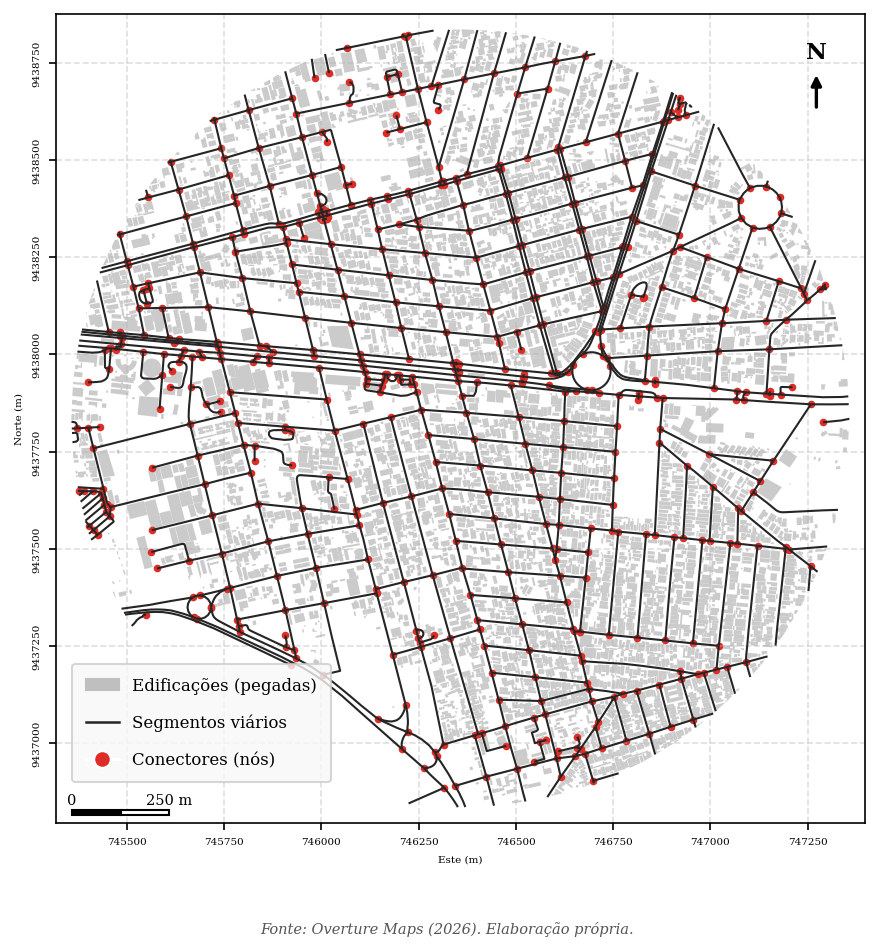

In [10]:
# ── 3. MAPA: DETALHE DA TOPOLOGIA (rede viária + edificações) ────────────────
gdf_bld = gpd.read_file(EXT_OVERTURE / "zonaUrbana_building_utm.geojson")   # camada pesada (lida sob demanda)
centro = gdf_zu.geometry.iloc[0].centroid
janela = centro.buffer(1000)                                               # recorte de 1 km de raio
seg_z = gpd.clip(gdf_seg, janela)
con_z = gpd.clip(gdf_con, janela)
bld_z = gpd.clip(gdf_bld, janela)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor("#FFFFFF")

bld_z.plot(ax=ax, color="#BFBFBF", edgecolor="none", alpha=0.8)            # edificações
seg_z.plot(ax=ax, color="#252525", linewidth=1.0)                         # ruas (arestas)
con_z.plot(ax=ax, color="#DE2D26", markersize=7)                          # conectores (nós)

ax.legend(
    handles=[
        mpatches.Patch(color="#BFBFBF", label="Edificações (pegadas)"),
        Line2D([0], [0], color="#252525", lw=1.2, label="Segmentos viários"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#DE2D26", markersize=8, label="Conectores (nós)"),
        ],
    loc="lower left",
    fontsize=8,
    bbox_to_anchor=(0.01, 0.04),  # <-- Empurra a legenda 4% para cima, fugindo da escala
)

ajustar_zoom_camada(ax, seg_z, margem=0.02)
moldura_mapa(ax, "", "Overture Maps (2026). Elaboração própria.")
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax, comprimento_m=250, rotulo="250 m")
seta_norte(ax)
fig.savefig(FIGURAS_NB / "nb014_fig02_topologia_detalhe.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Próximos passos

As aquisições estão consolidadas e validadas visualmente. O roteiro segue para o **NB 01.5** (análise exploratória socioeconômica) e o **NB 02.1** (limpeza e correção topológica da malha viária).